# 01 订单级分析宽表与样本规则

本 Notebook 验收从原始运单表加工出的订单级宽表，并冻结后续诊断和运力策略使用的样本。

业务问题不是“删掉多少异常”，而是：不同分析目的应该使用哪个分母，以及筛选是否会系统性改变结论。

## 管理摘要

- 订单宽表共 **568,546 行**，`order_id` 完全唯一；其中 **568,545 单**有完整送达结果。
- 高峰运力策略主样本定义为：**有效完成 + 即时单 + 已知商圈**，共 **436,062 单**。
- 全部有效完成订单准时率为 **84.99%**，策略样本为 **86.37%**。筛选会提高准时率，因此策略样本不能替代全城经营大盘。
- 预订单准时率约 **79.32%**，即时单约 **85.22%**；未知商圈订单准时率约 **80.69%**，低于已知商圈约 **86.09%**。该结果为描述性差异，不能直接解释为因果关系。
- 一条已完成订单缺失派单时间，仍纳入准时率，但不进入派单阶段时长分析。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MART_PATH = PROJECT_ROOT / "data" / "processed" / "order_fulfillment_mart.parquet"
assert MART_PATH.exists(), MART_PATH
orders = pd.read_parquet(MART_PATH)

print(f"rows={len(orders):,}, columns={orders.shape[1]}, unique_orders={orders['order_id'].nunique():,}")
orders.head(3)

rows=568,546, columns=73, unique_orders=568,546


,source_row_id,dt,order_id,waybill_id,courier_id,da_id,is_courier_grabbed,is_weekend,estimate_arrived_time,is_prebook,poi_id,sender_lng,sender_lat,recipient_lng,recipient_lat,grab_lng,grab_lat,dispatch_time,grab_time,fetch_time,arrive_time,estimate_meal_prepare_time,accepted_waybill_order_push_time,accepted_waybill_platform_order_time,waybill_attempt_count,accepted_waybill_count,platform_order_time,order_push_time,first_dispatch_time,last_dispatch_time,rejected_waybill_count,wave_id,wave_start_time,wave_end_time,wave_order_count,platform_order_time_local,order_push_time_local,accepted_waybill_platform_order_time_local,accepted_waybill_order_push_time_local,first_dispatch_time_local,dispatch_time_local,grab_time_local,fetch_time_local,arrive_time_local,estimate_arrived_time_local,estimate_meal_prepare_time_local,wave_start_time_local,wave_end_time_local,service_date,push_time_slot_30m,push_hour,push_weekday,order_to_push_minutes,first_dispatch_wait_minutes,accepted_dispatch_wait_minutes,accepted_dispatch_to_grab_minutes,order_push_to_accept_minutes,accept_to_pickup_minutes,pickup_to_delivery_minutes,total_fulfillment_minutes,promise_minutes,signed_late_minutes,late_minutes,is_dispatch_timeline_valid,is_valid_completed,is_on_time,is_late,late_severity,merchant_customer_distance_km,courier_merchant_distance_at_accept_km,is_on_demand,is_known_da,is_strategy_eligible
0,1,20221017,1,1,1,1,1,1,1665937864,0,1,174529930,45905850,174522983,45898250,174530062,45906005,1665936734,1665936737,1665937344,1665937798,1665936845,1665936006,1665935995,2,1,1665935995,1665936006,1665936558,1665936734,1,1.0000,"1,665,936,737.0000","1,665,937,798.0000",1.0000,2022-10-16 23:59:55,2022-10-17 00:00:06,2022-10-16 23:59:55,2022-10-17 00:00:06,2022-10-17 00:09:18,2022-10-17 00:12:14,2022-10-17 00:12:17,2022-10-17 00:22:24,2022-10-17 00:29:58,2022-10-17 00:31:04,2022-10-17 00:14:05,2022-10-17 00:12:17,2022-10-17 00:29:58,2022-10-17,2022-10-17,0,0,0.1833,9.2000,12.1333,0.0500,12.1833,10.1167,7.5667,30.0500,31.1500,-1.1000,0.0000,True,True,True,False,on_time,1.0016,0.0200,True,True,True
1,2,20221017,2,2,2,2,1,0,1665939504,0,2,174532407,45861460,174547033,45891243,174548244,45870923,1665937484,1665937501,1665938346,1665939384,1665938007,1665937107,1665937097,1,1,1665937097,1665937107,1665937484,1665937484,0,1.0000,"1,665,938,277.0000","1,665,939,955.0000",4.0000,2022-10-17 00:18:17,2022-10-17 00:18:27,2022-10-17 00:18:17,2022-10-17 00:18:27,2022-10-17 00:24:44,2022-10-17 00:24:44,2022-10-17 00:25:01,2022-10-17 00:39:06,2022-10-17 00:56:24,2022-10-17 00:58:24,2022-10-17 00:33:27,2022-10-17 00:37:57,2022-10-17 01:05:55,2022-10-17,2022-10-17,0,0,0.1667,6.2833,6.2833,0.2833,6.5667,14.0833,17.3000,38.1167,40.1167,-2.0000,0.0000,True,True,True,False,on_time,3.4999,1.6158,True,True,True
2,3,20221017,3,3,3,0,1,0,1665939432,0,3,174559718,45868015,174595327,45886787,174560199,45867948,1665937394,1665937397,1665937830,1665939822,1665937634,1665937369,1665937028,1,1,1665937028,1665937369,1665937394,1665937394,0,1.0000,"1,665,937,397.0000","1,665,939,822.0000",2.0000,2022-10-17 00:17:08,2022-10-17 00:22:49,2022-10-17 00:17:08,2022-10-17 00:22:49,2022-10-17 00:23:14,2022-10-17 00:23:14,2022-10-17 00:23:17,2022-10-17 00:30:30,2022-10-17 01:03:42,2022-10-17 00:57:12,2022-10-17 00:27:14,2022-10-17 00:23:17,2022-10-17 01:03:42,2022-10-17,2022-10-17,0,0,5.6833,0.4167,0.4167,0.0500,0.4667,7.2167,33.2000,46.5667,40.0667,6.5000,6.5000,True,True,False,True,late_0_10m,3.4577,0.0380,True,False,False


## 1. 主键、时间链路和覆盖检查

这里用硬性断言把主表契约写进分析流程。后续任何加工破坏唯一性或覆盖数，Notebook 都应执行失败。

In [2]:
assert orders["order_id"].is_unique
assert len(orders) == 568_546
assert int(orders["is_valid_completed"].sum()) == 568_545
assert int(orders["wave_id"].notna().sum()) == 568_545
assert int(orders["is_dispatch_timeline_valid"].sum()) == 568_545

quality_contract = pd.Series({
    "order_rows": len(orders),
    "unique_orders": orders["order_id"].nunique(),
    "valid_completed": int(orders["is_valid_completed"].sum()),
    "wave_matches": int(orders["wave_id"].notna().sum()),
    "valid_dispatch_timeline": int(orders["is_dispatch_timeline_valid"].sum()),
    "duplicate_orders": int(orders["order_id"].duplicated().sum()),
}, name="value")
quality_contract.to_frame()

,value
order_rows,568546
unique_orders,568546
valid_completed,568545
wave_matches,568545
valid_dispatch_timeline,568545
duplicate_orders,0


## 2. 样本漏斗

三个筛选各自解决不同问题：

- 有效完成：结果指标有可靠分母；
- 即时单：匹配高峰即时需求与运力配置场景；
- 已知商圈：策略能落到具体运营单元。

In [3]:
sample_funnel = pd.DataFrame([
    {"stage": "Accepted order", "orders": len(orders)},
    {"stage": "Valid completed", "orders": int(orders["is_valid_completed"].sum())},
    {"stage": "Valid + on-demand", "orders": int((orders["is_valid_completed"] & orders["is_on_demand"]).sum())},
    {"stage": "Strategy eligible", "orders": int(orders["is_strategy_eligible"].sum())},
])
sample_funnel["retained_vs_all_pct"] = sample_funnel["orders"].div(len(orders)).mul(100)
sample_funnel

,stage,orders,retained_vs_all_pct
0,Accepted order,568546,100.0000
1,Valid completed,568545,99.9998
2,Valid + on-demand,546364,96.0985
3,Strategy eligible,436062,76.6978


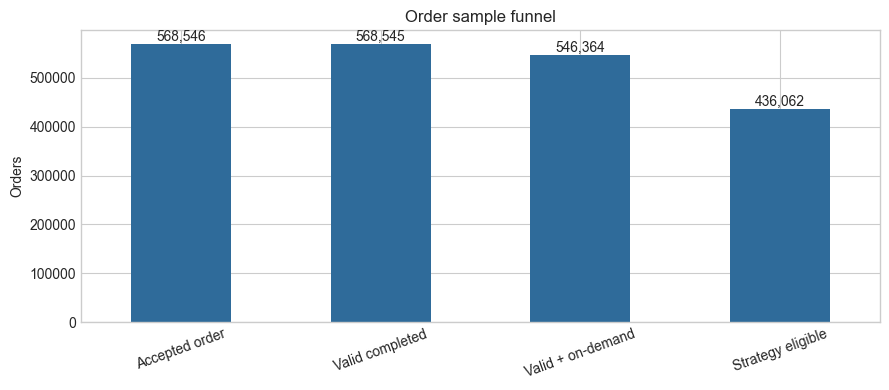

In [4]:
ax = sample_funnel.plot(
    x="stage", y="orders", kind="bar", legend=False, figsize=(9, 4), color="#2F6B9A"
)
ax.set_title("Order sample funnel")
ax.set_xlabel("")
ax.set_ylabel("Orders")
ax.tick_params(axis="x", rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")
plt.tight_layout()
plt.show()

## 3. 筛选偏差检查

如果被排除样本的准时率不同，只报策略样本会让全城水平看起来更好或更差。因此总体经营指标和可执行策略样本必须并列报告。

In [5]:
valid = orders.loc[orders["is_valid_completed"]].copy()

segment_comparison = pd.concat([
    valid.groupby("is_prebook", observed=True).agg(
        orders=("order_id", "size"), on_time_rate=("is_on_time", "mean")
    ).rename(index={0: "on_demand", 1: "prebook"}),
    valid.groupby("is_known_da", observed=True).agg(
        orders=("order_id", "size"), on_time_rate=("is_on_time", "mean")
    ).rename(index={False: "unknown_da", True: "known_da"}),
])
segment_comparison["on_time_rate_pct"] = segment_comparison["on_time_rate"].mul(100)
segment_comparison

,orders,on_time_rate,on_time_rate_pct
on_demand,546364,0.8522,85.2219
prebook,22181,0.7932,79.3246
unknown_da,115138,0.8069,80.6867
known_da,453407,0.8609,86.0851


In [6]:
kpi_scope = pd.DataFrame([
    {
        "scope": "all_valid_completed",
        "orders": len(valid),
        "on_time_rate_pct": valid["is_on_time"].mean() * 100,
    },
    {
        "scope": "strategy_eligible",
        "orders": int(orders["is_strategy_eligible"].sum()),
        "on_time_rate_pct": orders.loc[orders["is_strategy_eligible"], "is_on_time"].mean() * 100,
    },
])
kpi_scope

,scope,orders,on_time_rate_pct
0,all_valid_completed,568545,84.9919
1,strategy_eligible,436062,86.3652


**解释边界：** 预订单和未知商圈的准时率较低是已观察到的相关性，不足以证明“预订”或“区域未知”导致超时。可能还混入时段、距离、商家、承诺时长和数据采集机制差异。

## 4. 订单级过程指标分布

所有时长均保留原值。表格报告 P50/P90/P99/最大值；后续画图可以截尾，但不能悄悄删除长尾。

In [7]:
stage_columns = [
    "order_to_push_minutes",
    "first_dispatch_wait_minutes",
    "accepted_dispatch_wait_minutes",
    "accepted_dispatch_to_grab_minutes",
    "accept_to_pickup_minutes",
    "pickup_to_delivery_minutes",
    "total_fulfillment_minutes",
    "promise_minutes",
    "late_minutes",
]

strategy = orders.loc[orders["is_strategy_eligible"]].copy()
stage_summary = strategy[stage_columns].quantile([0.5, 0.9, 0.99, 0.999, 1.0]).T
stage_summary.columns = ["p50", "p90", "p99", "p999", "max"]
stage_summary

,p50,p90,p99,p999,max
order_to_push_minutes,0.2000,1.7167,12.1167,31.1480,293.7500
first_dispatch_wait_minutes,1.1167,6.4833,16.7333,28.7500,72.4167
accepted_dispatch_wait_minutes,1.2333,6.9333,17.3232,30.1833,84.7833
accepted_dispatch_to_grab_minutes,0.1833,0.7333,4.8667,15.7167,95.2500
accept_to_pickup_minutes,9.1167,18.2167,29.0667,41.5490,96.5000
pickup_to_delivery_minutes,12.2000,26.4833,41.3000,54.9833,342.9000
total_fulfillment_minutes,26.7833,44.1667,61.5833,81.7167,366.5667
promise_minutes,33.6833,50.0167,65.1833,85.0990,265.0833
late_minutes,0.0000,1.4833,11.3500,29.2813,326.3500


In [8]:
distance_summary = strategy[
    ["merchant_customer_distance_km", "courier_merchant_distance_at_accept_km"]
].quantile([0.5, 0.9, 0.99, 0.999, 1.0]).T
distance_summary.columns = ["p50", "p90", "p99", "p999", "max"]
distance_summary

,p50,p90,p99,p999,max
merchant_customer_distance_km,1.3644,2.6741,4.4102,7.2537,14.3771
courier_merchant_distance_at_accept_km,0.4686,1.2978,2.3987,3.6256,19.6347


## 5. 超时严重程度

严重程度阈值是项目分析分层，不是美团内部 SLA。准时率之外必须同时看超时订单规模和长尾。

In [9]:
severity = (
    valid["late_severity"]
    .value_counts(sort=False)
    .rename_axis("late_severity")
    .to_frame("orders")
)
severity["share_pct"] = severity["orders"].div(len(valid)).mul(100)
severity

,orders,share_pct
late_severity,,
on_time,483217,84.9919
late_0_10m,77048,13.5518
late_10_30m,7514,1.3216
late_30m_plus,766,0.1347


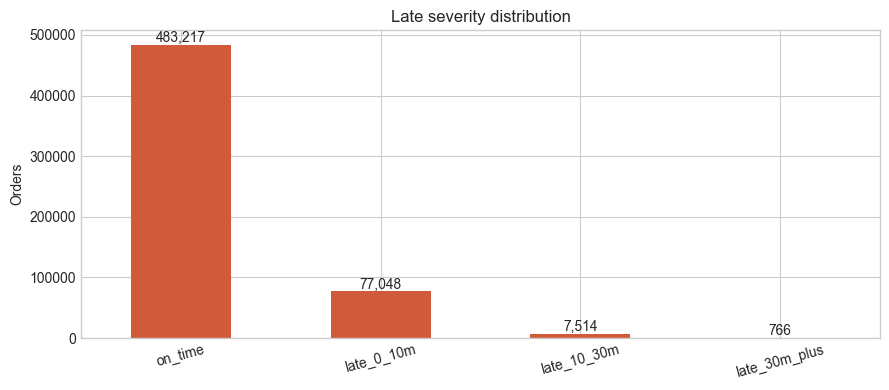

In [10]:
ax = severity["orders"].plot(kind="bar", figsize=(9, 4), color="#D05A3A")
ax.set_title("Late severity distribution")
ax.set_xlabel("")
ax.set_ylabel("Orders")
ax.tick_params(axis="x", rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")
plt.tight_layout()
plt.show()

## 6. 宽表使用契约

| 场景 | 样本 | 注意事项 |
|---|---|---|
| 全城准时率 | `is_valid_completed` | 包含预订单和未知商圈 |
| 商圈时段诊断 | `is_strategy_eligible` | 结果不能外推为全城大盘 |
| 派单阶段分析 | 再加 `is_dispatch_timeline_valid` | 缺失派单时点的订单不参与该阶段 |
| 预订单专项 | `is_valid_completed & ~is_on_demand` | 与即时单分开分析 |
| 模型训练 | 按业务日期切分策略样本 | 禁止使用随机切分替代跨期留出验证 |

下一步在策略样本上建立“全城 → 日期 → 小时 → 商圈 × 30 分钟”的指标树，并判断哪些延误阶段与运力更相关。

## Sources

- `data/processed/order_fulfillment_mart.parquet`
- `docs/05_sample_and_table_rules.md`
- `scripts/build_order_mart.py`